In [ ]:
# ICU Mortality Prediction Project
# Author: Your Name
# Dataset: MIMIC
# Models: Logistic Regression, Decision Tree, Random Forest, SVM

In [3]:
import pandas as pd
df = pd.read_csv('Assignment1_mimic dataset.csv') 
print(df.shape)
df.head()

(65366, 140)


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,deathtime,icu_death_flag,...,ck_mb_min,ck_mb_max,ggt_min,ggt_max,ld_ldh_min,ld_ldh_max,so2_min,so2_max,po2_min,po2_max
0,10270110,20171261,35854639,PACU,PACU,2134-03-25T03:32:02Z,2134-03-25T14:20:42Z,0.450463,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10270644,20019675,35548343,PACU,PACU,2159-12-03T16:20:31Z,2159-12-08T17:28:42Z,5.047350,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10464753,28216499,32421516,PACU,PACU,2183-01-10T20:51:04Z,2183-01-11T22:58:45Z,1.088669,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10710188,21362776,34067486,PACU,PACU,2147-06-22T11:48:40Z,2147-06-23T11:35:59Z,0.991192,2147-06-23T14:21:00Z,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10826759,28468289,37075137,PACU,PACU,2121-05-19T18:07:00Z,2121-05-20T16:32:39Z,0.934479,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
missing_data = df.isnull().mean() * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print(missing_data.head(90))
df['hospital_expire_flag'].value_counts(normalize=True)

thrombin_min      99.947985
thrombin_max      99.947985
ggt_max           99.839366
ggt_min           99.839366
globulin_min      99.750635
                    ...    
so2_min           76.296546
so2_max           76.296546
po2_min           52.577793
po2_max           52.577793
marital_status    10.248447
Length: 90, dtype: float64


hospital_expire_flag
0    0.891595
1    0.108405
Name: proportion, dtype: float64

In [5]:
df = df.drop(columns=['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'deathtime', 'icu_death_flag' , 'los'])

high_missing_cols = df.columns[df.isnull().mean() > 0.5]
df = df.drop(columns=high_missing_cols)

df.head()
print(df.shape)

(65366, 42)


In [6]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(exclude=['object']).columns

for col in cat_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

df[num_cols] = df[num_cols].fillna(df[num_cols].median())


df = pd.get_dummies(df, columns = cat_cols , drop_first=True)



print(df.shape)

print(df.isnull().values.any())

(65366, 101)
False


In [7]:
print(df.head())


   hospital_expire_flag  age  sofa2_respiration_24h_max  \
0                     0   78                        0.0   
1                     0   91                        0.0   
2                     0   86                        0.0   
3                     1   86                        0.0   
4                     0   77                        0.0   

   sofa2_cardiovascular_24h_max  sofa2_coagulation_24h_max  \
0                           0.0                        0.0   
1                           0.0                        0.0   
2                           0.0                        0.0   
3                           0.0                        0.0   
4                           0.0                        2.0   

   sofa2_liver_24h_max  sofa2_renal_24h_max  sofa2_cns_24h_max  \
0                  0.0                  0.0                0.0   
1                  0.0                  0.0                2.0   
2                  0.0                  0.0                0.0   
3       

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV


X = df.drop(columns=['hospital_expire_flag'])
y = df['hospital_expire_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y )


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)



lasso_logit = LogisticRegressionCV(
    Cs=20, cv=5, penalty='l1', solver='liblinear', class_weight='balanced', random_state=42,n_jobs=-1
).fit(X_train_s, y_train)

In [10]:
coef = pd.Series(lasso_logit.coef_[0], index=X.columns)
imp_coef = coef.sort_values()

selected_features = X.columns[lasso_logit.coef_[0] != 0]
print(selected_features)

Index(['spo2_min', 'gcs_motor', 'gcs_eyes'], dtype='object')


gcs_motor   -0.077797
gcs_eyes    -0.011367
spo2_min    -0.002735
dtype: float64


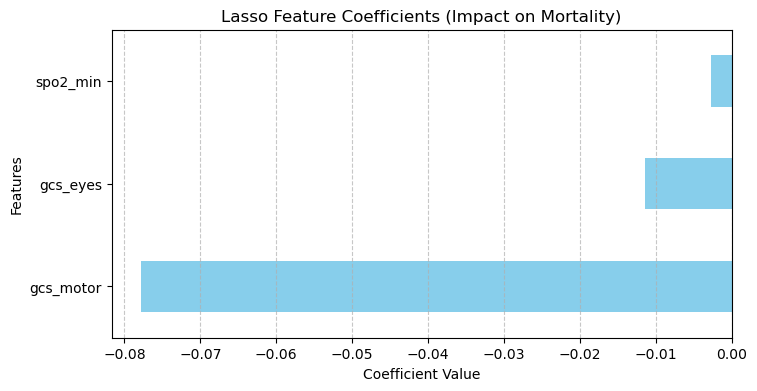

In [18]:
active_coefs = imp_coef[imp_coef != 0]
print(active_coefs)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
active_coefs.plot(kind='barh', color='skyblue')
plt.title('Lasso Feature Coefficients (Impact on Mortality)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [13]:
print(lasso_logit.C_)

[0.0001]


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score


X_train_3 = X_train[selected_features]
X_test_3 = X_test[selected_features]

scaler_3 = StandardScaler()
X_train_3_s = scaler_3.fit_transform(X_train_3)
X_test_3_s = scaler_3.transform(X_test_3)


models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced'),
    "SVM": SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)
}

for name, model in models.items():
    model.fit(X_train_3_s, y_train)
    y_prob = model.predict_proba(X_test_3_s)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f"{name} AUC: {auc:.4f}")

Logistic Regression AUC: 0.7705
Decision Tree AUC: 0.7798
Random Forest AUC: 0.7611
SVM AUC: 0.7692


0.8676344531219304


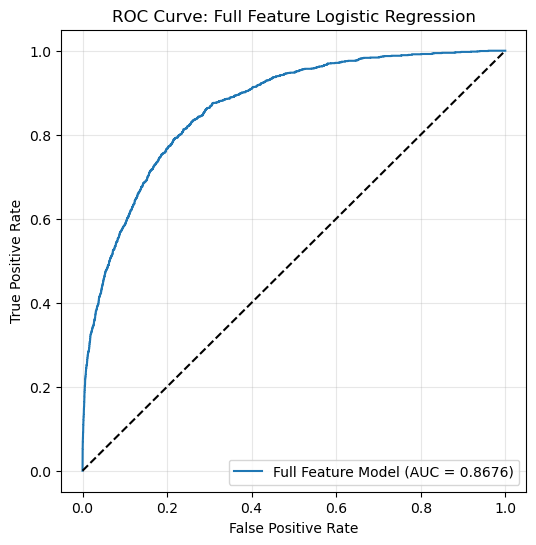

In [33]:
from sklearn.metrics import roc_curve, auc
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegressionCV(class_weight='balanced')
model.fit(X_train_s, y_train)

y_prob = model.predict_proba(X_test_s)[:,1]
auc_full = roc_auc_score(y_test, y_prob)

print(auc_full)

y_prob_full = model.predict_proba(X_test_s)[:, 1] 
fpr, tpr, _ = roc_curve(y_test, y_prob_full)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Full Feature Model (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Full Feature Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)

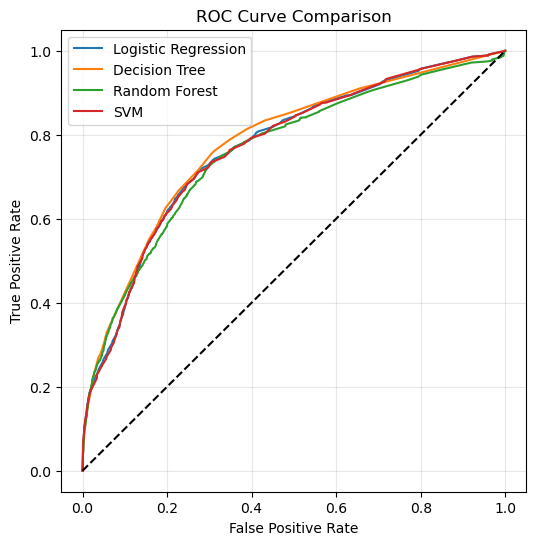

In [36]:
from sklearn.metrics import roc_curve
plt.figure(figsize=(6,6))

for name, model in models.items():
    model.fit(X_train_3_s, y_train)
    y_prob = model.predict_proba(X_test_3_s)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

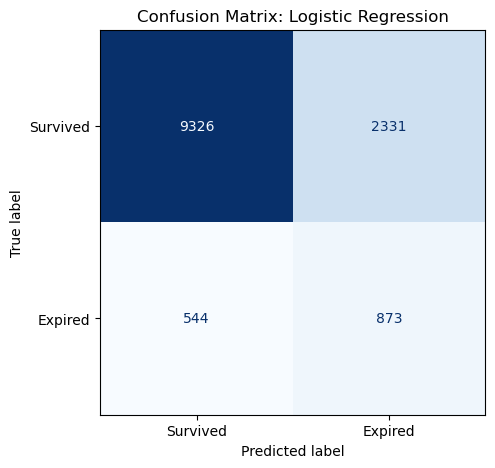

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

    Survived       0.94      0.80      0.87     11657
     Expired       0.27      0.62      0.38      1417

    accuracy                           0.78     13074
   macro avg       0.61      0.71      0.62     13074
weighted avg       0.87      0.78      0.81     13074



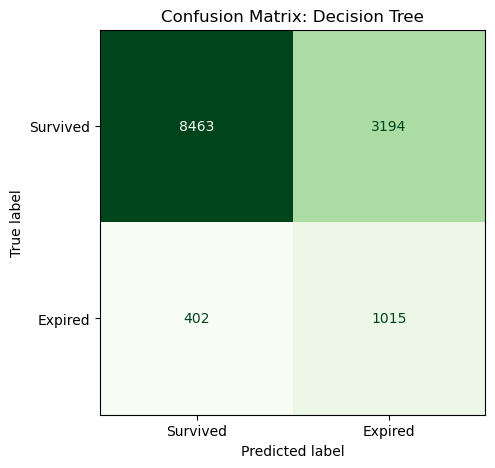

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

    Survived       0.95      0.73      0.82     11657
     Expired       0.24      0.72      0.36      1417

    accuracy                           0.72     13074
   macro avg       0.60      0.72      0.59     13074
weighted avg       0.88      0.72      0.77     13074



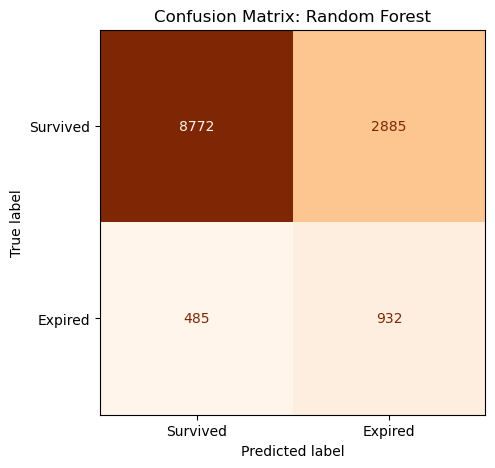

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

    Survived       0.95      0.75      0.84     11657
     Expired       0.24      0.66      0.36      1417

    accuracy                           0.74     13074
   macro avg       0.60      0.71      0.60     13074
weighted avg       0.87      0.74      0.79     13074



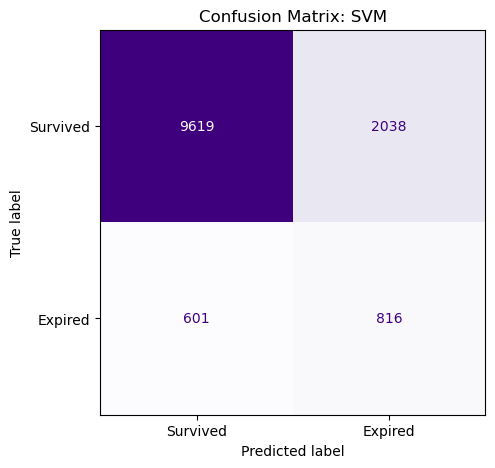

--- SVM Classification Report ---
              precision    recall  f1-score   support

    Survived       0.94      0.83      0.88     11657
     Expired       0.29      0.58      0.38      1417

    accuracy                           0.80     13074
   macro avg       0.61      0.70      0.63     13074
weighted avg       0.87      0.80      0.83     13074



In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"]
colors = ['Blues', 'Greens', 'Oranges', 'Purples']


for i, name in enumerate(model_names):
    model = models[name]
    y_pred = model.predict(X_test_3_s)    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=['Survived', 'Expired']
    )
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(cmap=colors[i], ax=ax, colorbar=False)     
    plt.title(f"Confusion Matrix: {name}")
    plt.show()
    
    print(f"--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=['Survived', 'Expired']))

In [25]:
import joblib


joblib.dump(models['Decision Tree'],  'best_dt_model_3features.pkl')
joblib.dump(models['Random Forest'],  'best_rf_model_3features.pkl')
joblib.dump(models['Logistic Regression'],  'best_lr_model_3features.pkl')
joblib.dump(models['SVM'],  'best_svm_model_3features.pkl')


joblib.dump(lasso_logit, 'full_feature_lasso_model.pkl')
#loaded_model = joblib.load('best_dt_model_3features.pkl')

['full_feature_lasso_model.pkl']